In [83]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

# Funzioni

In [84]:
def percento(vals, percento):
    f1, f2 = vals
    delta = abs(f1 - f2)
    incremento = delta * percento / 100
    return [f1 - incremento, f2 + incremento]

In [85]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

In [86]:
import matplotlib.mathtext as mathtext

# funzione per gestire latex in modo intelligente
def latex_safe(s):
    try:
        test = rf"$\{s}$"
        mathtext.MathTextParser("agg").parse(test, dpi=100)
        return test
    except:
        return rf"${s}$"

In [87]:
def griglia_XY(x, sx, y, sy):
    risoluzione = 30
    x_range = np.linspace(x - sx, x + sx, risoluzione)
    y_range = np.linspace(y - sy, y + sy, risoluzione)
    return np.meshgrid(x_range, y_range)

In [88]:
# Funzione senza la modifica di Chat per le cifre degli assi
def grafico_chi(x, sx, y, sy, chi_quadri, xlabel, ylabel):

    # Creazione dei dati per il grafico
    X, Y = griglia_XY(x, sx, y, sy)

    # Creazione dei limiti del grafico
    zoom = 50
    x_range = [x - sx, x + sx]
    y_range = [y - sy, y + sy]
    z_range = [chi_quadri.min(), chi_quadri.max()]
    xlim = percento(x_range, zoom)
    ylim = percento(y_range, zoom)
    zlim = percento(z_range, zoom)

    # Label sistemate per problemi con latex
    xlabel_latex = latex_safe(xlabel)
    ylabel_latex = latex_safe(ylabel)
    titolo = rf"$\chi^2 ( {xlabel_latex[1:-1]}, {ylabel_latex[1:-1]} )$"
    # [1:-1] serve a togliere i $...$ interni

    # Creazione del grafico 3D
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection='3d')
    gf.parametri_grafico(ax, titolo, xlabel=xlabel_latex, ylabel=ylabel_latex, zlabel=r"$\chi^2$", tridimensionale=True)
    ax.view_init(elev=20, azim=-60)
    ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

    # Elementi del grafico
    ax.scatter(X, Y, chi_quadri, **gf.scatter_params)
    ax.plot_surface(X, Y, chi_quadri, cmap='coolwarm')
    ax.contourf(X, Y, chi_quadri, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, chi_quadri, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, chi_quadri, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)

    # Salvataggio del grafico
    gf.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}.pdf")

In [89]:
def grafico_chi(x, sx, y, sy, chi_quadri, xlabel, ylabel):

    import matplotlib.mathtext as mathtext
    from matplotlib.ticker import FuncFormatter
    import numpy as np

    # -------- LATEX SAFE --------
    def latex_safe(s):
        try:
            test = rf"$\{s}$"
            mathtext.MathTextParser("agg").parse(test, dpi=100)
            return test
        except:
            return rf"${s}$"

    # -------- FORMAT NUMERI --------
    def axis_formatter(values):
        max_val = max(abs(values.min()), abs(values.max()))

        if max_val == 0:
            scale = 1
        else:
            exp = int(np.floor(np.log10(max_val)))
            scale = 10**exp if abs(exp) > 2 else 1  # soglia per notazione scientifica

        def formatter(x, pos):
            val = x / scale
            return f"{val:.3g}"  # max 3 cifre totali

        return formatter, scale

    # -------- DATI --------
    X, Y = griglia_XY(x, sx, y, sy)

    zoom = 50
    x_range = np.array([x - sx, x + sx])
    y_range = np.array([y - sy, y + sy])
    z_range = np.array([chi_quadri.min(), chi_quadri.max()])

    xlim = percento(x_range, zoom)
    ylim = percento(y_range, zoom)
    zlim = percento(z_range, zoom)

    # -------- LABEL --------
    xlabel_latex = latex_safe(xlabel)
    ylabel_latex = latex_safe(ylabel)

    titolo = rf"$\chi^2 ( {xlabel_latex[1:-1]}, {ylabel_latex[1:-1]} )$"

    # -------- FIGURA --------
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection='3d')

    gf.parametri_grafico(
        ax,
        titolo,
        xlabel=xlabel_latex,
        ylabel=ylabel_latex,
        zlabel=r"$\chi^2$",
        tridimensionale=True
    )

    ax.view_init(elev=20, azim=-60)
    ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

    # -------- FORMAT ASSI --------
    fx, scalex = axis_formatter(x_range)
    fy, scaley = axis_formatter(y_range)
    fz, scalez = axis_formatter(z_range)

    ax.xaxis.set_major_formatter(FuncFormatter(fx))
    ax.yaxis.set_major_formatter(FuncFormatter(fy))
    ax.zaxis.set_major_formatter(FuncFormatter(fz))

    # aggiungi fattore scientifico nel label se serve
    if scalex != 1:
        ax.set_xlabel(rf"{xlabel_latex} $\times 10^{{{int(np.log10(scalex))}}}$")
    if scaley != 1:
        ax.set_ylabel(rf"{ylabel_latex} $\times 10^{{{int(np.log10(scaley))}}}$")
    if scalez != 1:
        ax.set_zlabel(rf"$\chi^2$ $\times 10^{{{int(np.log10(scalez))}}}$")

    # -------- GRAFICO --------
    ax.scatter(X, Y, chi_quadri, **gf.scatter_params)
    ax.plot_surface(X, Y, chi_quadri, cmap='coolwarm')

    ax.contourf(X, Y, chi_quadri, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, chi_quadri, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
    ax.contourf(X, Y, chi_quadri, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)

    # -------- SALVATAGGIO --------
    gf.salva_grafico(fig, f"Chi/{xlabel}_{ylabel}.pdf", tridimensionale=True)

# Lettura Dati

In [90]:
anal,xdata,ydata = gf.importa_pickle("analisi.pkl")

def modello(par, x):
    a,b,d = par
    return a/b * np.exp(- ( x ) / d ) * ( 1/d * np.sin(b * ( x ) ) + b * np.cos(b * ( x ) ) )

Creazione array per v, omega e tau

In [91]:
[[v0, s_v], [omega0, s_omega], [tau0, s_tau]] = anal

Creazione array per R, L e C

# Grafici

## 1. Omega e Tau

Creazione griglia chi

In [92]:
O, T = griglia_XY(omega0, s_omega, tau0, s_tau)

chi_quadri = np.zeros_like(O)
for i in range(O.shape[0]):
    for j in range(O.shape[1]):
        parametri = [anal[0][0], O[i, j], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

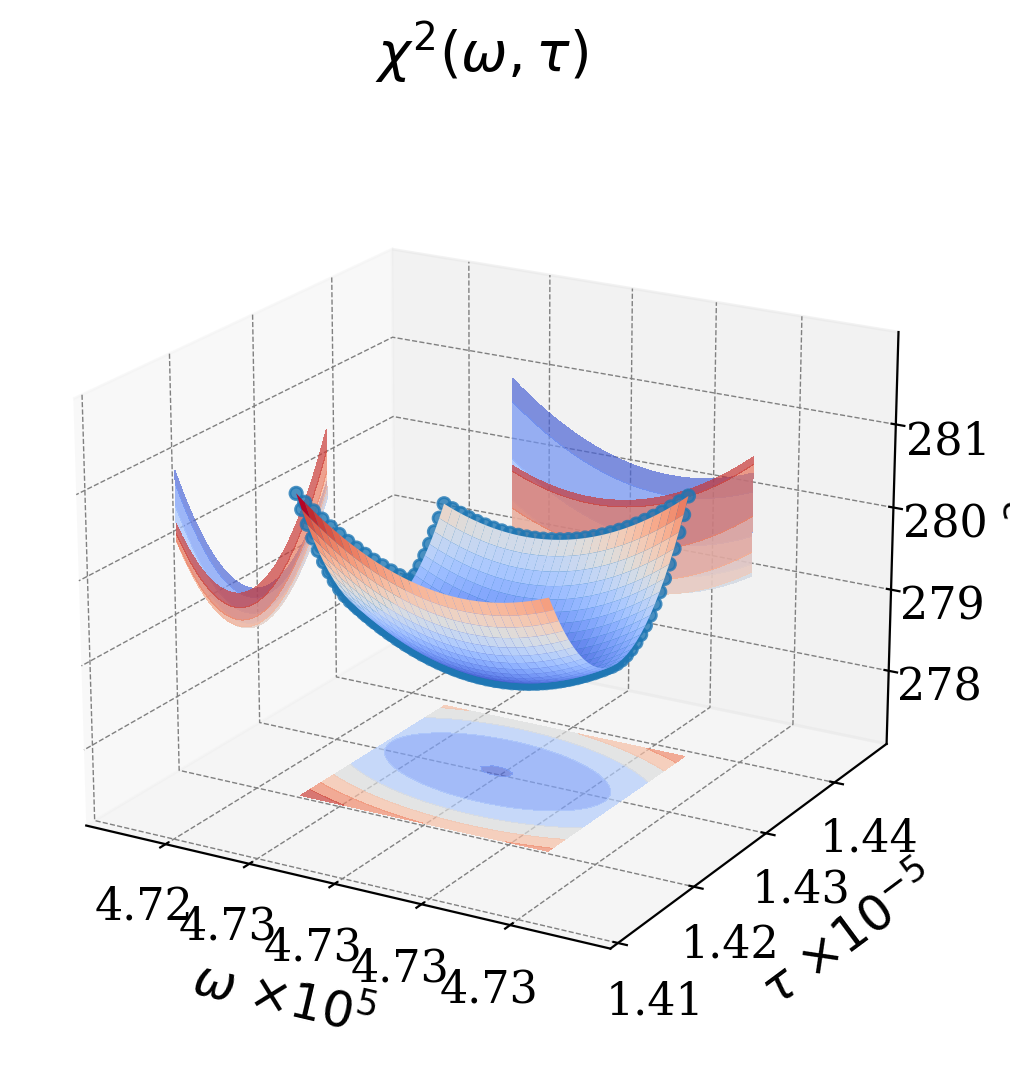

In [93]:
grafico_chi(omega0, s_omega, tau0, s_tau, chi_quadri, "omega", "tau")

In [94]:
"""
fig = plt.figure()

ax1 = fig.add_subplot(2,2,2)
gf.parametri_grafico(ax1,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$")
colore = ax1.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')
fig.colorbar(colore, ax=ax1, label=r"$\chi^2$")

ax2 = fig.add_subplot(2,2,1)
gf.parametri_grafico(ax2,r"$\chi^2 ( \tau )$",xlabel=r"$\tau$",ylabel=r"$\chi^2$")
ax2.scatter(T, chi_quadri, **gf.scatter_params)

ax3 = fig.add_subplot(2,2,4)
gf.parametri_grafico(ax3,r"$\chi^2 ( \omega )$",xlabel=r"$\omega$",ylabel=r"$\chi^2$")
ax3.scatter(O, chi_quadri, **gf.scatter_params)

gf.salva_grafico(fig,"Chi/omega_tau_2d.pdf")
"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3504/1759256506.py:1: SyntaxWarning: invalid escape sequence '\c'
  """


'\nfig = plt.figure()\n\nax1 = fig.add_subplot(2,2,2)\ngf.parametri_grafico(ax1,r"$\\chi^2 ( \tau,\\omega )$",xlabel=r"$\\omega$",ylabel=r"$\tau$")\ncolore = ax1.pcolormesh(O, T, chi_quadri, shading=\'auto\', cmap=\'viridis\')\nfig.colorbar(colore, ax=ax1, label=r"$\\chi^2$")\n\nax2 = fig.add_subplot(2,2,1)\ngf.parametri_grafico(ax2,r"$\\chi^2 ( \tau )$",xlabel=r"$\tau$",ylabel=r"$\\chi^2$")\nax2.scatter(T, chi_quadri, **gf.scatter_params)\n\nax3 = fig.add_subplot(2,2,4)\ngf.parametri_grafico(ax3,r"$\\chi^2 ( \\omega )$",xlabel=r"$\\omega$",ylabel=r"$\\chi^2$")\nax3.scatter(O, chi_quadri, **gf.scatter_params)\n\ngf.salva_grafico(fig,"Chi/omega_tau_2d.pdf")\n'

## 2. V e Tau

Creazione griglia chi

In [95]:
V, T = griglia_XY(v0, s_v, tau0, s_tau)

chi_quadri = np.zeros_like(V)
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        parametri = [V[i, j], anal[1][0], T[i, j]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

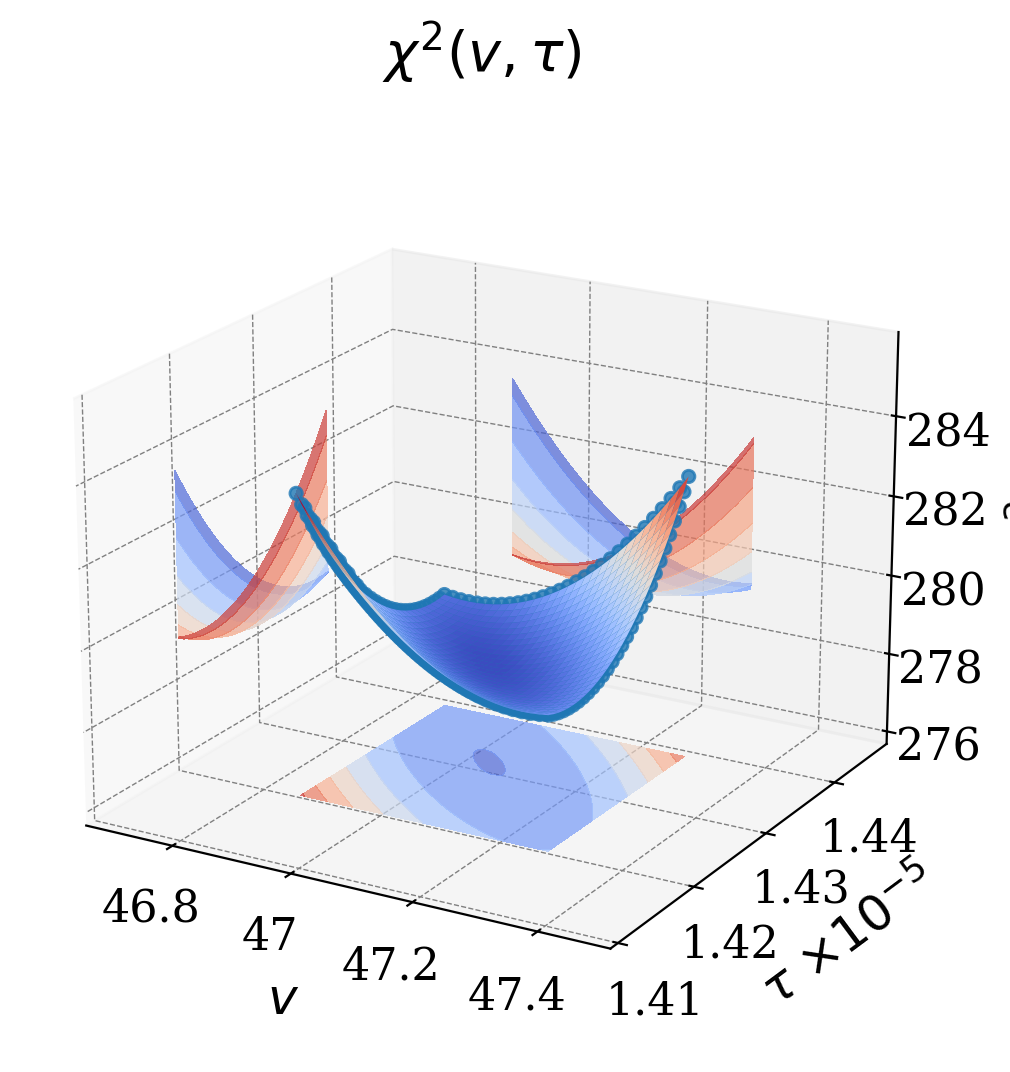

In [96]:
grafico_chi(v0, s_v, tau0, s_tau, chi_quadri, "v", "tau")

In [97]:
"""
fig, ax = plt.subplots()
gf.parametri_grafico(ax,r"$\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$")

colore = ax.pcolormesh(V, T, chi_quadri, shading='auto', cmap='viridis')

fig.colorbar(colore, ax=ax, label=r"$\chi^2$")

gf.salva_grafico(fig,"Chi/v_tau_2d.pdf")
"""

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3504/2278907907.py:1: SyntaxWarning: invalid escape sequence '\c'
  """


'\nfig, ax = plt.subplots()\ngf.parametri_grafico(ax,r"$\\chi^2 ( \tau, v_0 )$",xlabel=r"$v_0$",ylabel=r"$\tau$")\n\ncolore = ax.pcolormesh(V, T, chi_quadri, shading=\'auto\', cmap=\'viridis\')\n\nfig.colorbar(colore, ax=ax, label=r"$\\chi^2$")\n\ngf.salva_grafico(fig,"Chi/v_tau_2d.pdf")\n'